In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset from a CSV file
data = pd.read_csv('/content/sample_data/avian_data.csv')
print(data.head())

# Display information about the DataFrame
print(data.info())
print(data.describe(include='all'))

# Create a new 'Date' column by combining 'Year' and 'Month'
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))

# Plot the total number of cases over time
# plt.figure(figsize=(12, 6))
# data.groupby('Date')['Cases'].sum().plot()
# plt.title('Total Cases Over Time')
# plt.xlabel('Date')
# plt.ylabel('Number of Cases')
# plt.grid(True)
# plt.show()

# # Plot total cases by region using a bar plot
# plt.figure(figsize=(12, 6))
# sns.barplot(data=data.groupby('Region')['Cases'].sum().reset_index(), x='Region', y='Cases')
# plt.title('Total Cases by Region')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# # Plot the frequency of different diagnoses using a count plot
# plt.figure(figsize=(10, 5))
# sns.countplot(data=data, y='Diagnosis', order=data['Diagnosis'].value_counts().index)
# plt.title('Diagnosis Frequency')
# plt.tight_layout()
# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/sample_data/avian_data.csv'

   Year  Month              Region                              County  \
0  2012      6  Yorkshire & Humber                     North Yorkshire   
1  2012     12     East of England                       Hertfordshire   
2  2012     10               Wales                    North West Wales   
3  2012      5  Yorkshire & Humber  East Riding and North Lincolnshire   
4  2012      3  Yorkshire & Humber                     North Yorkshire   

  Age Category             Clinical Sign             Diagnosis  Cases  \
0     0-7 Days                   Unknown  Yolk Sack\nInfection      2   
1        Adult              Non-specific       Marek's Disease      1   
2        adult                 Recumbent           Manutrition      1   
3     0-7 Days                   Unknown  Yolk Sack\nInfection      1   
4        Adult  Musculoskeletal&/or Lame       Marek's Disease      1   

   Temparature  Poultry Density  Outbreak Logistics Regression  
0         15.1             55.2                    

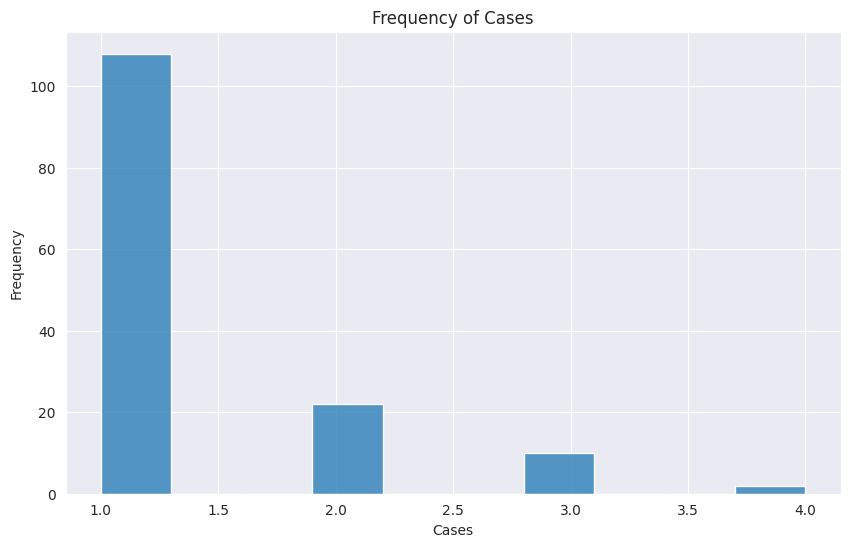

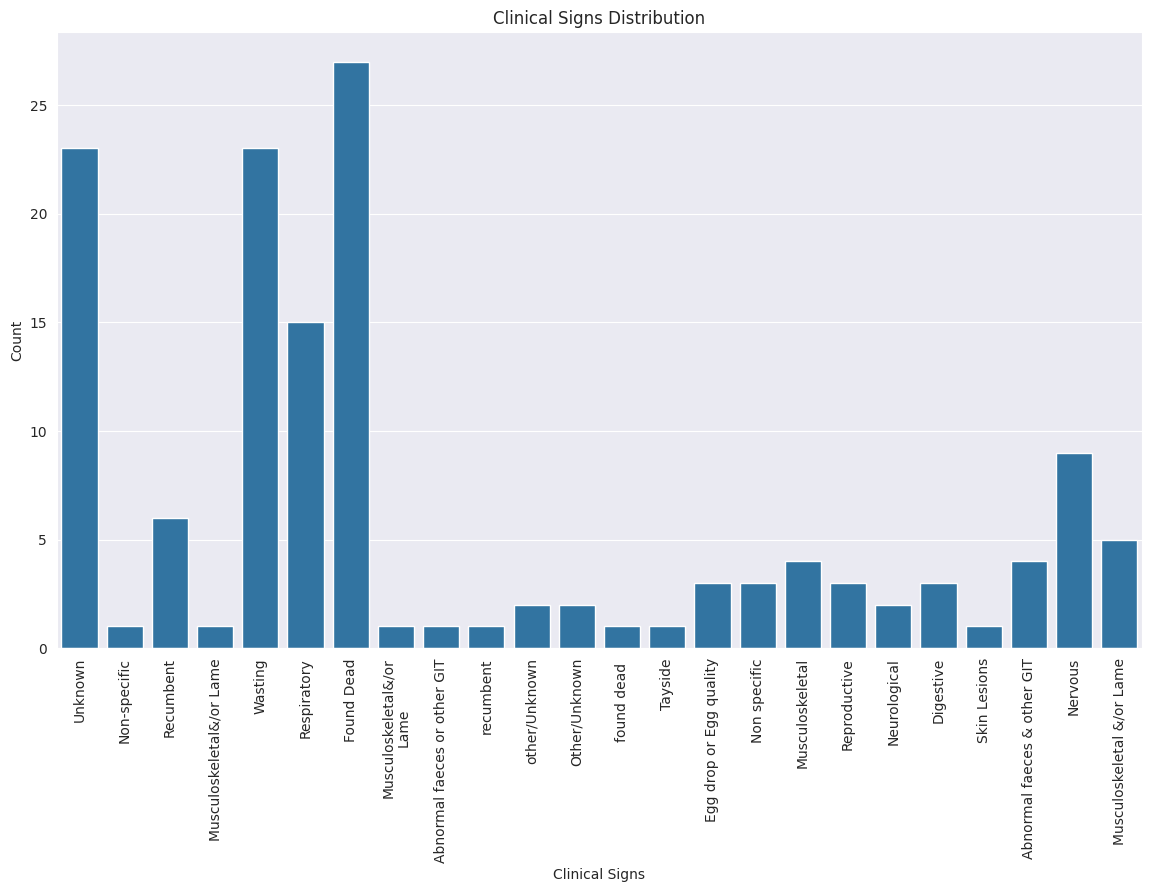

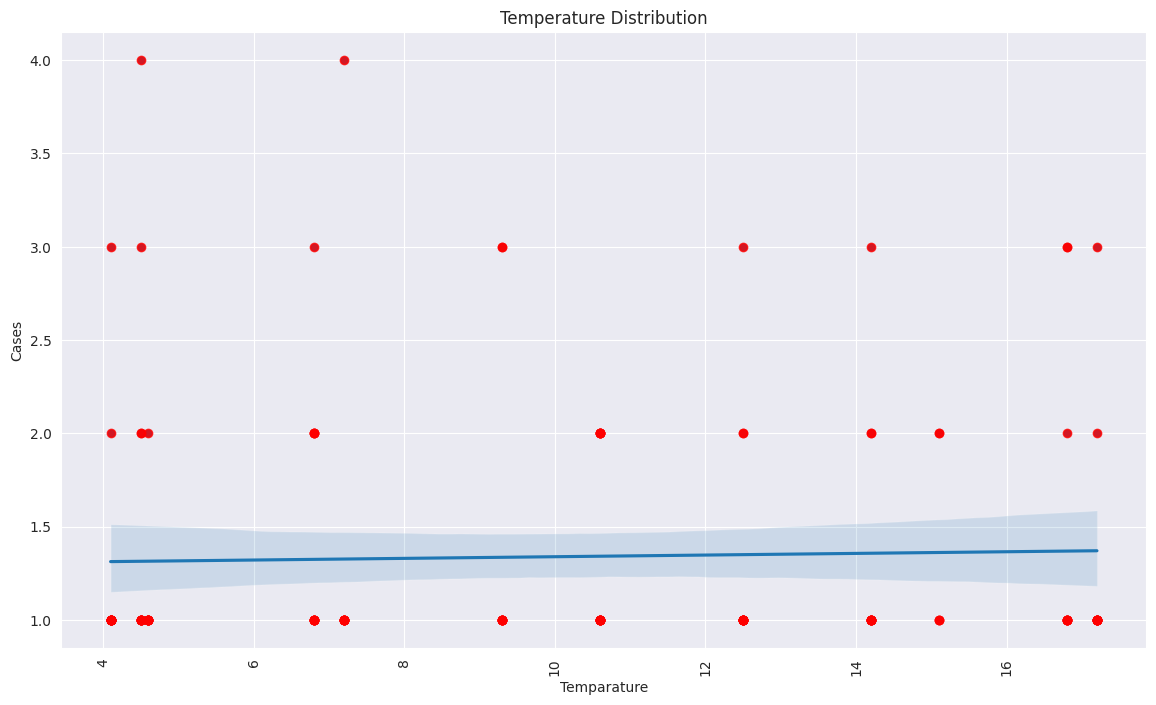

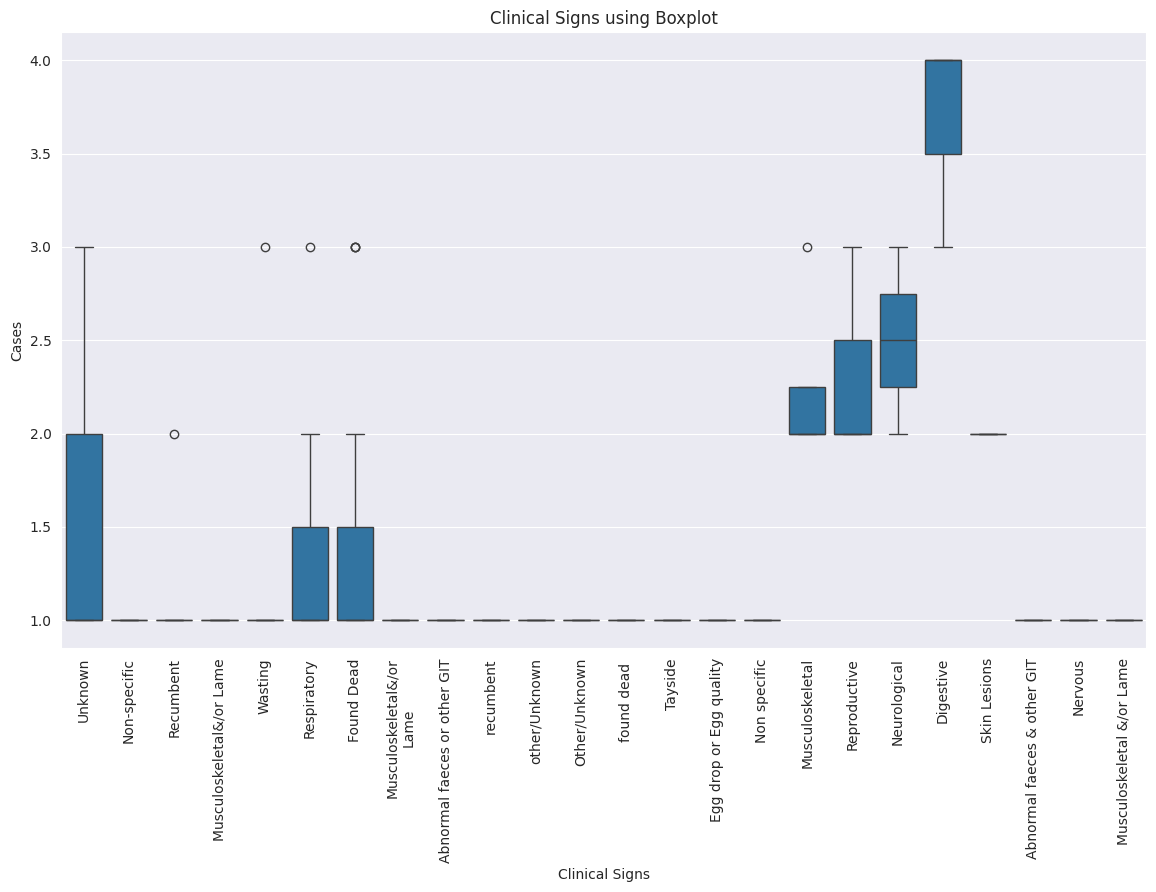

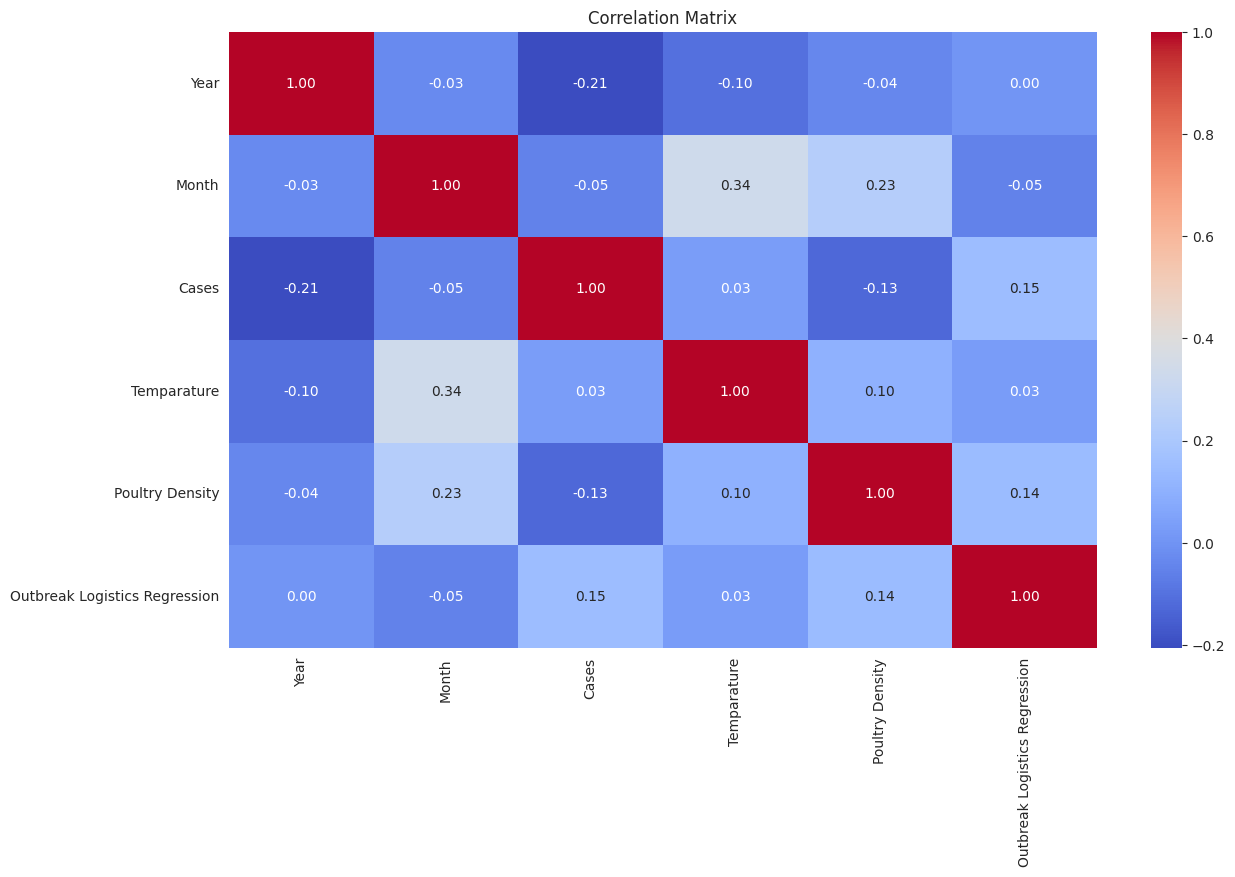

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv('/content/sample_data/avian_data.csv')
print(data.head())
print(data.describe())
print(data.dtypes)

#Univariate (One variable at a time)
# Frequency on total cases (Histogram)

sns.set_style('darkgrid')
plt.figure(figsize=(10,6))
sns.histplot(data['Cases'],bins=10, kde=False)
plt.title('Frequency of Cases')
plt.xlabel('Cases')
plt.ylabel('Frequency')
plt.show()

# Clinical Signs count (Counter plot)

plt.figure(figsize=(14,8))
sns.countplot(data=data, x='Clinical Sign')
plt.title('Clinical Signs Distribution')
plt.xlabel('Clinical Signs')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()


#Bivariate
# Scatter Plot (Temperature vs Cases)
plt.figure(figsize=(14,8))
sns.scatterplot(data=data, x='Temparature', y='Cases')
sns.regplot(data=data, x='Temparature', y='Cases',scatter_kws={'color':'red'})
plt.title('Temperature Distribution')
plt.xlabel('Temparature')
plt.ylabel('Cases')
plt.xticks(rotation=90)
plt.show()


#Box Plot  (Clinical signs vs Cases)
plt.figure(figsize=(14,8))
sns.boxplot(data=data, x='Clinical Sign', y='Cases')
plt.title('Clinical Signs using Boxplot')
plt.xlabel('Clinical Signs')
plt.ylabel('Cases')
plt.xticks(rotation=90)
plt.show()

#Heatmap
numerical_data = data.select_dtypes(include=['float64','int64'])
correlation_matrix = numerical_data.corr()
plt.figure(figsize=(14,8))
sns.heatmap(data=correlation_matrix, annot=True,cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

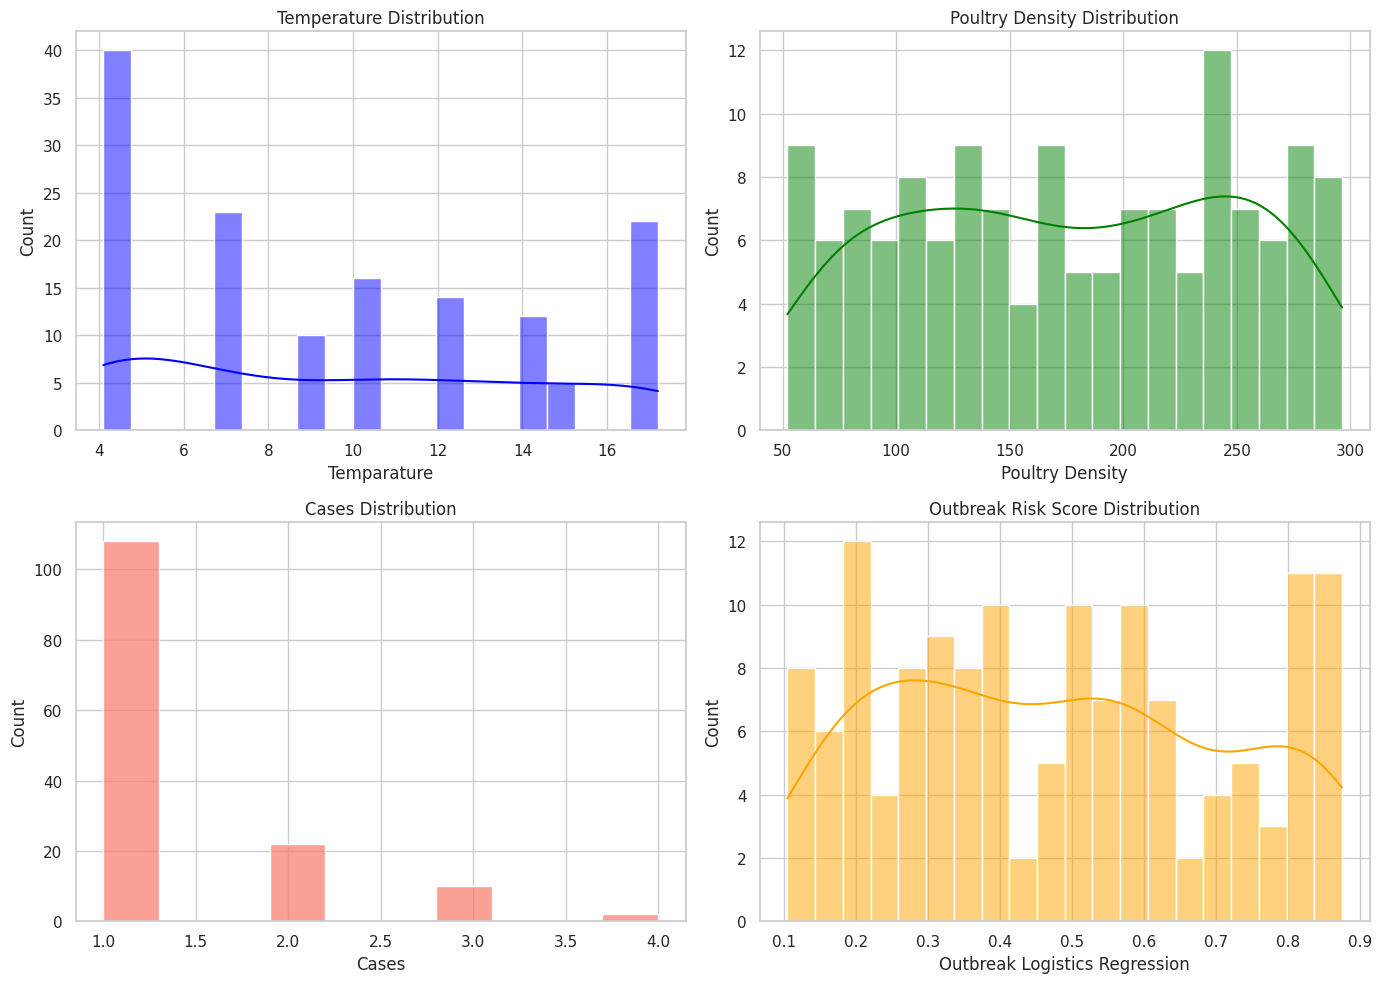

In [ ]:
import seaborn as sns

# Configure seaborn to use a white grid style
sns.set(style="whitegrid")

# Create subplots to visualize the distribution of numerical features
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot the distribution of temperature with a histogram and kernel density estimate
sns.histplot(data['Temparature'], bins=20, kde=True, ax=axes[0, 0], color='blue')
axes[0, 0].set_title('Temperature Distribution')

# Plot the distribution of poultry density
sns.histplot(data['Poultry Density'], bins=20, kde=True, ax=axes[0, 1], color='green')
axes[0, 1].set_title('Poultry Density Distribution')

# Plot the distribution of cases without a kernel density estimate
sns.histplot(data['Cases'], bins=10, kde=False, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Cases Distribution')

# Plot the distribution of outbreak risk scores
sns.histplot(data['Outbreak Logistics Regression'], bins=20, kde=True, ax=axes[1, 1], color='orange')
axes[1, 1].set_title('Outbreak Risk Score Distribution')

# Adjust layout to prevent overlap and display the plots
plt.tight_layout()
plt.show()

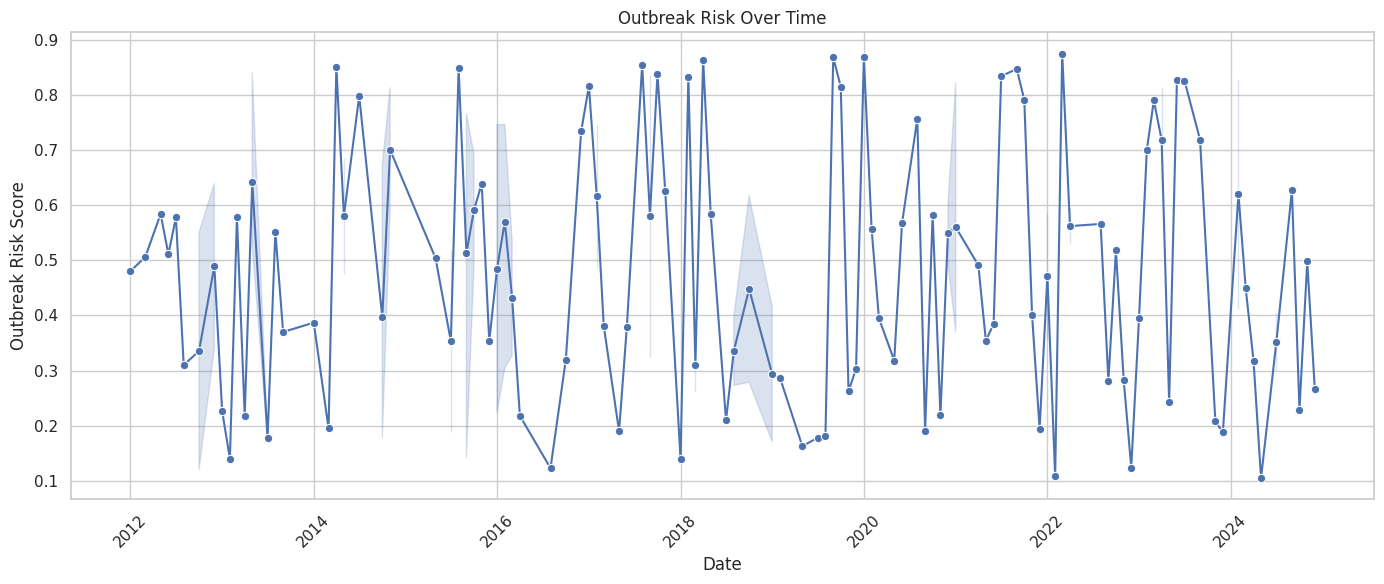

In [ ]:
# Create a datetime column for analyzing time-based analysis
data['Date'] = pd.to_datetime(data[['Year', 'Month']].assign(DAY=1))

# Generate a line plot to illustrate outbreak risk over time
plt.figure(figsize=(14, 6))
sns.lineplot(x='Date', y='Outbreak Logistics Regression', data=data, marker='o')
plt.title('Outbreak Risk Over Time')
plt.xlabel('Date')
plt.ylabel('Outbreak Risk Score')
plt.xticks(rotation=45)  # Rotate the x-axis labels for improved readability
plt.tight_layout()  # Optimize layout to avoid overlap
plt.show()  # Render the plot

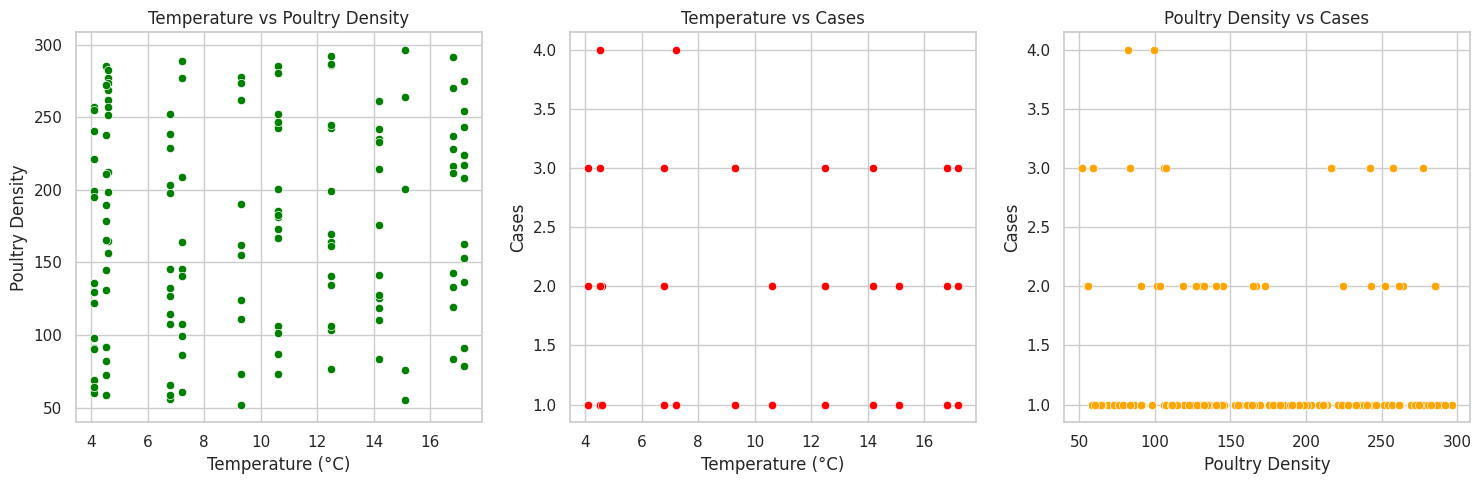

In [ ]:
# Create scatter plots to analyze the relationships between key variables
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Scatter plot for Temperature against Poultry Density
sns.scatterplot(x=data['Temparature'], y=data['Poultry Density'], ax=axes[0], color='green')
axes[0].set_title('Temperature vs Poultry Density')
axes[0].set_xlabel('Temperature (°C)')
axes[0].set_ylabel('Poultry Density')

# Scatter plot for Temperature against Cases
sns.scatterplot(x=data['Temparature'], y=data['Cases'], ax=axes[1], color='red')
axes[1].set_title('Temperature vs Cases')
axes[1].set_xlabel('Temperature (°C)')
axes[1].set_ylabel('Cases')

# Scatter plot for Poultry Density against Cases
sns.scatterplot(x=data['Poultry Density'], y=data['Cases'], ax=axes[2], color='orange')
axes[2].set_title('Poultry Density vs Cases')
axes[2].set_xlabel('Poultry Density')
axes[2].set_ylabel('Cases')

plt.tight_layout()  # Optimize layout to avoid overlap
plt.show()  # Render the plots

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# Prepare the data for modeling
# For Linear Regression, we will use 'Outbreak Logistics Regression' as the target variable
X = data[['Temparature', 'Poultry Density']]  # Features
y_linear = data['Outbreak Logistics Regression']  # Target variable for linear regression

# For Logistic Regression, we will create a binary target for 'Cases' (1 if there is an outbreak, 0 if not)
y_logistic = (data['Cases'] > 1).astype(int)  # 1 if Cases > 1, otherwise 0

# Split the data into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train_linear, y_test_linear = train_test_split(X, y_linear, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.2, random_state=42)

# Scale the features for the regression models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Linear Regression Model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train_linear)
y_pred_linear = linear_reg_model.predict(X_test_scaled)

# Compute Mean Squared Error for the Linear Regression model
mse = mean_squared_error(y_test_linear, y_pred_linear)

# Logistic Regression Model
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train_scaled, y_train_log)
y_pred_log = log_reg_model.predict(X_test_scaled)

# Compute Accuracy for the Logistic Regression model
log_acc = accuracy_score(y_test_log, y_pred_log)

mse, log_acc

(0.049478748058440665, 0.6551724137931034)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Prepare the dataset
X = data[['Temparature', 'Poultry Density']]  # Features
y_linear = data['Outbreak Logistics Regression']  # Target variable for linear regression

# Split the dataset into training and testing sets
X_train, X_test, y_train_linear, y_test_linear = train_test_split(X, y_linear, test_size=0.2, random_state=42)

# Scale the feature values
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Fit the Linear Regression model
linear_reg_model = LinearRegression()
linear_reg_model.fit(X_train_scaled, y_train_linear)

# Generate predictions and compute Mean Squared Error (MSE)
y_pred_linear = linear_reg_model.predict(X_test_scaled)
mse = mean_squared_error(y_test_linear, y_pred_linear)

print(f'Mean Squared Error (Linear Regression): {mse}')

Mean Squared Error (Linear Regression): 0.049478748058440665


In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Prepare the target variable
y_logistic = (data['Cases'] > 1).astype(int)  # Binary target variable (1 for Outbreak, 0 for No Outbreak)

# Split the dataset into training and testing subsets
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_logistic, test_size=0.2, random_state=42)

# Scale the feature data
X_train_scaled = scaler.fit_transform(X_train_log)
X_test_scaled = scaler.transform(X_test_log)

# Fit the Logistic Regression model
log_reg_model = LogisticRegression()
log_reg_model.fit(X_train_scaled, y_train_log)

# Generate predictions and compute the accuracy
y_pred_log = log_reg_model.predict(X_test_scaled)
log_acc = accuracy_score(y_test_log, y_pred_log)

print(f'Accuracy of Logistic Regression: {log_acc}')

Accuracy of Logistic Regression: 0.6551724137931034


In [ ]:
# Import the required libraries and reload the dataset
import pandas as pd
from scipy.stats import ttest_rel
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, accuracy_score
from sklearn.preprocessing import StandardScaler

# Reload the dataset
data = pd.read_csv('/content/sample_data/avian_data.csv')

# Prepare the features and target variables for modeling
features = data[['Temparature', 'Poultry Density']]  # Features

# Define the target variable for Linear Regression
target_linear = data['Outbreak Logistics Regression']  # Target for linear regression

# Create a binary target variable for Logistic Regression based on 'Cases'
target_logistic = (data['Cases'] > 1).astype(int)  # 1 if Cases > 1, otherwise 0

# Split the dataset into training and testing sets (80% for training, 20% for testing)
X_train, X_test, y_train_linear, y_test_linear = train_test_split(features, target_linear, test_size=0.2, random_state=42)
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(features, target_logistic, test_size=0.2, random_state=42)

# Standardize the feature data for the regression models
scaler = StandardScaler()
X_train_standardized = scaler.fit_transform(X_train)
X_test_standardized = scaler.transform(X_test)

# Fit the Linear Regression model
linear_model = LinearRegression()
linear_model.fit(X_train_standardized, y_train_linear)
predictions_linear = linear_model.predict(X_test_standardized)

# Fit the Logistic Regression model
logistic_model = LogisticRegression()
logistic_model.fit(X_train_standardized, y_train_log)
predictions_logistic = logistic_model.predict(X_test_standardized)

# Calculate the residuals for both models
residuals_linear = y_test_linear - predictions_linear
residuals_logistic = y_test_log - predictions_logistic

# Conduct a paired t-test on the residuals
t_statistic, p_value = ttest_rel(residuals_linear, residuals_logistic)

t_statistic, p_value

(np.float64(-4.311290051643703), np.float64(0.00018146219252036664))